# Autoencoder and Decision Tree on Credit Card Dataset

Google Colab compatible version (fixed data loading).

In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense


In [4]:

# Load dataset
data = pd.read_csv('creditcard2.csv')
print(data.head(5))

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [5]:
data.isna().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [6]:
data.isnull().values.any()

np.True_

In [7]:
# Check data
print(data.info())
print(data['Class'].value_counts())  # Class = 0 (normal), 1 (fraud)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64036 entries, 0 to 64035
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    64036 non-null  int64  
 1   V1      64036 non-null  float64
 2   V2      64036 non-null  float64
 3   V3      64036 non-null  float64
 4   V4      64036 non-null  float64
 5   V5      64036 non-null  float64
 6   V6      64036 non-null  float64
 7   V7      64036 non-null  float64
 8   V8      64036 non-null  float64
 9   V9      64036 non-null  float64
 10  V10     64036 non-null  float64
 11  V11     64036 non-null  float64
 12  V12     64036 non-null  float64
 13  V13     64036 non-null  float64
 14  V14     64035 non-null  float64
 15  V15     64035 non-null  float64
 16  V16     64035 non-null  float64
 17  V17     64035 non-null  float64
 18  V18     64035 non-null  float64
 19  V19     64035 non-null  float64
 20  V20     64035 non-null  float64
 21  V21     64035 non-null  float64
 22

In [8]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,64036.000000,64036.000000,64036.000000,64036.000000,64036.000000,64036.000000,64036.000000,64036.000000,64036.000000,64036.000000,...,64035.000000,64035.000000,64035.000000,64035.000000,64035.000000,64035.000000,64035.000000,64035.000000,64035.000000,64035.000000
mean,33034.739069,-0.239372,-0.013276,0.684992,0.172259,-0.266174,0.103322,-0.113967,0.059874,0.043301,...,-0.028136,-0.107563,-0.039013,0.005831,0.136321,0.020247,0.001964,0.004140,96.233670,0.002592
std,13977.443205,1.857410,1.653721,1.429700,1.380437,1.391521,1.306522,1.250983,1.190321,1.172576,...,0.717525,0.636550,0.604305,0.596285,0.439167,0.497960,0.383121,0.322085,270.937838,0.050849
min,0.000000,-56.407510,-72.715728,-32.965346,-5.172595,-42.147898,-26.160506,-26.548144,-41.484823,-9.283925,...,-20.262054,-10.933144,-26.751119,-2.836627,-7.495741,-2.534330,-8.567638,-9.617915,0.000000,0.000000
25%,27446.250000,-0.998982,-0.587029,0.199835,-0.724038,-0.884543,-0.636257,-0.604527,-0.142923,-0.659781,...,-0.227416,-0.527978,-0.179537,-0.325275,-0.127561,-0.329416,-0.063032,-0.005912,7.680000,0.000000
50%,36606.000000,-0.242090,0.074661,0.775116,0.189248,-0.298502,-0.149384,-0.073715,0.064634,-0.053898,...,-0.062340,-0.082496,-0.051721,0.061181,0.174094,-0.075702,0.009266,0.022717,26.310000,0.000000
75%,43463.250000,1.154323,0.730490,1.409311,1.054695,0.273578,0.494569,0.422286,0.341634,0.703757,...,0.114071,0.307953,0.079357,0.402460,0.422302,0.297008,0.082423,0.076191,88.010000,0.000000
max,50993.000000,1.960497,18.183626,4.226108,16.715537,34.801666,22.529298,36.677268,20.007208,10.392889,...,22.614889,5.805795,17.297845,4.014444,5.525093,3.517346,11.135740,33.847808,19656.530000,1.000000


In [9]:
data.drop('Time', axis=1, inplace=True)
X = data.drop('Class', axis=1)
y = data['Class']
X.shape, y.shape

((64036, 29), (64036,))

In [10]:
temp_df = data.copy()

# Scale 'Amount' (optional, Time can be dropped)
standard = StandardScaler()
amount = temp_df['Amount'].values
temp_df['Amount'] = standard.fit_transform(amount.reshape(-1,1))
X_scaled = temp_df.drop('Class', axis=1)
y_scaled = temp_df['Class']

X_scaled.shape, y_scaled.shape

# Train autoencoder ONLY on normal transactions
X_normal = X_scaled[y == 0]

# Train-validation split
X_train, X_test = train_test_split(X_normal, test_size=0.3, random_state=42)


In [11]:
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))

# Encoder
encoder = Dense(64, activation="relu")(input_layer)
encoder = Dense(32, activation="relu")(encoder)
encoder = Dense(16, activation="relu")(encoder)   # bottleneck

# Decoder
decoder = Dense(32, activation="relu")(encoder)
decoder = Dense(64, activation="relu")(decoder)
decoder = Dense(input_dim, activation="linear")(decoder)

# Autoencoder model
model = Model(inputs=input_layer, outputs=decoder)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
)

model.summary()

history = model.fit(
    X_train, X_train,
    epochs=10,
    batch_size=256,
    validation_data=(X_test, X_test),
    shuffle=True
)



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 29)             │         1,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,069 (35.43 KB)

 Trainable params: 9,069 (35.43 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.8847 - val_loss: 0.4037
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3375 - val_loss: 0.2130
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1852 - val_loss: 0.1498
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1391 - val_loss: 0.1180
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1165 - val_loss: 0.1017
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1023 - val_loss: 0.0910
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0864 - val_loss: 0.0862
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0781 - val_loss: 0.0764
Epoch 9/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0721 - val_loss: 0.0713
Epoch 10/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0679 - val_loss: 0.0644


In [12]:

# Reconstruct all transactions
X_pred = model.predict(X_scaled)

# Compute reconstruction error
reconstruction_error = np.mean(np.square(X_scaled - X_pred), axis=1)



2002/2002 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [13]:
threshold = np.percentile(reconstruction_error[y == 0], 99)

print("Anomaly threshold:", threshold)


Anomaly threshold: 0.5338835600488326


In [14]:
y_pred_autoencoder = (reconstruction_error > threshold).astype(int)


Test Reconstruction Loss (MSE): 0.064416


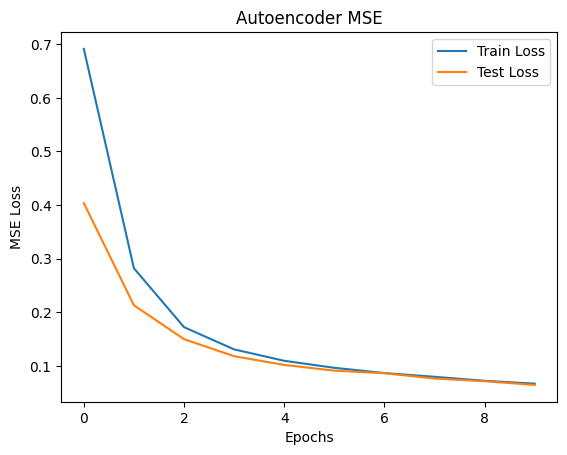

In [15]:
# Evaluate the model (Autoencoder)
test_loss = model.evaluate(X_test, X_test, verbose=0)
print(f"Test Reconstruction Loss (MSE): {test_loss:.6f}")

# Plot training & validation accuracy values
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Autoencoder MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()
